### 매출 기반 판매자 집단 분석
- 군집 분석을 통해 판매자 유형을 탐색적으로 파악한 이후, 실제 판매 성과와 연결되는 요인을 보다 명확히 이해하기 위해 매출 기준 판매자 분류 분석을 추가적으로 수행하였다. 
- 실제로 비즈니스적으로 의미 있는 기준인 “매출”을 기준으로 판매자를 구분한 뒤,
- 각 집단의 특성을 비교하고, 마지막에는 고매출 판매자를 예측하는 지도학습 모델로 핵심 요인을 검증하는 방식

### 흐름
→ 판매자 매출 분포 확인
→ 매출 기준 seller segmentation
→ 그룹별 특성 비교
→ 통계 검정
→ 고매출 판매자 예측 모델
→ feature importance로 성공 요인 해석
→ 플랫폼 전략 제안

1. 매출 기준 seller segmentation

먼저 판매자를 매출 또는 주문 수 기준으로 구간화

상위 10% 판매자

Non-top seller

이렇게 나누는 이유는, 이 프로젝트의 목표가 “자연 군집”을 찾는 것이 아니라 성과가 높은 판매자의 특징을 찾는 것이기 때문

2. 그룹별 특성 비교

그다음 각 seller 그룹의 평균 특성을 비교합니다.

비교할 수 있는 변수의 예

상품 다양성

평균 리뷰 점수

평균 배송 지연일

평균 가격

평균 배송비 혹은 배송비 비율

같은 주 배송 비율

판매 카테고리 집중도/분산도

이 단계의 목적은 간단합니다.

“상위 판매자는 일반 판매자와 실제로 어떤 점이 다른가?”

3. 통계 검정으로 차이 확인

그룹 간 평균 차이를 단순히 “보였다”가 아닌 통계 검정을 붙여야 함.

예를 들어:

두 그룹 비교: Mann-Whitney U test 또는 t-test

세 그룹 이상 비교: ANOVA 또는 Kruskal-Wallis

seller 특성 데이터는 종종 비정규적이고 롱테일이 심하므로, 비모수 검정이 더 자연스러움

여기서 확인하고 싶은 것은:

상위 판매자와 일반 판매자의 상품 다양성 차이가 우연이 아니라, 통계적으로도 유의한가?

결론 예시: 
상위 판매자 집단은 일반 판매자 집단에 비해 상품 다양성이 유의하게 높았으며, 이는 고매출 판매자의 주요 특성 중 하나일 가능성을 시사한다.

4. 고매출 판매자 예측 모델 만들기

target = 매출 상위 10% 여부

1 = 고매출 판매자

0 = 일반 판매자

이렇게 이진 분류 문제로 바꿈: 주어진 seller 특성으로 이 판매자가 고매출 seller인지 예측할 수 있는가?

5. 모델 성능의 의미

이 프로젝트에서 모델의 목적은 “엄청 높은 정확도 달성”이 아니라,
어떤 feature가 고매출 seller를 설명하는 데 중요한지 파악하는 것

완벽한 예측보다 더 중요한 것은:   
baseline보다 나은가?
그리고 feature importance가 일관되게 해석 가능한가?
- 비록 성능이 아주 높지 않더라도 feature importance는 seller 특성의 차이를 설명하는 도구로 활용할 수 있음

6. feature importance로 성공 요인 해석

RandomForest나 XGBoost 결과에서 중요 변수가 반복적으로 비슷하게 나오면,
그 변수는 고매출 판매자를 설명하는 핵심 변수라고 볼 수 있음

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
df_orders = pd.read_csv("data/olist_orders_dataset.csv")
df_order_items = pd.read_csv("data/olist_order_items_dataset.csv")
df_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
df_products = pd.read_csv("data/olist_products_dataset.csv")
df_sellers = pd.read_csv("data/olist_sellers_dataset.csv")
df_customers = pd.read_csv("data/olist_customers_dataset.csv")
df_category = pd.read_csv("data/product_category_name_translation.csv")

In [3]:
## 2. Convert Date Columns
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

df_reviews["review_creation_date"] = pd.to_datetime(df_reviews["review_creation_date"], errors="coerce")
df_reviews["review_answer_timestamp"] = pd.to_datetime(df_reviews["review_answer_timestamp"], errors="coerce")

In [4]:
## 3. Filter Valid Orders
df_orders_delivered = df_orders[df_orders["order_status"] == "delivered"].copy()
print("Delivered orders:", df_orders_delivered.shape)

Delivered orders: (96478, 8)


In [5]:
df_products = df_products.merge(
    df_category,
    on="product_category_name",
    how="left"
)

df_products["product_category_name_english"] = df_products["product_category_name_english"].fillna("product_category_name")

In [6]:
## 5. Merge Tables

df = (
    df_order_items
    .merge(df_orders_delivered, on="order_id", how="inner")
    .merge(df_reviews[["order_id", "review_score"]], on="order_id", how="left")
    .merge(df_products[["product_id", "product_category_name_english", "product_weight_g"]], on="product_id", how="left")
    .merge(df_sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    .merge(df_customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)

print(df.shape)
df.head()

(110840, 19)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,product_category_name_english,product_weight_g,seller_state,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,5.0,cool_stuff,650.0,SP,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,4.0,pet_shop,30000.0,SP,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,5.0,furniture_decor,3050.0,MG,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,4.0,perfumery,200.0,SP,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,5.0,garden_tools,3750.0,PR,SP


In [7]:
## 6. Create Derived Variables
# 배송 소요일
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

# 예상일 대비 지연일
df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# 지연 여부
df["is_delayed"] = (df["delay_days"] > 0).astype(int)

# 판매자와 고객이 같은 주인지
df["same_state"] = (df["seller_state"] == df["customer_state"]).astype(int)

# 배송비 비율
df["freight_ratio"] = df["freight_value"] / df["price"].replace(0, np.nan)

# 카테고리 결측 보정
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

In [8]:
## 7. Build Seller-Level Dataset
# We aggregate item-level transactions into seller-level features.
seller_df = (
    df.groupby("seller_id")
    .agg(
        total_sales=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_orders=("order_id", "nunique"),
        total_items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score", "mean"),
        avg_delivery_time=("delivery_time", "mean"),
        avg_delay_days=("delay_days", "mean"),
        delay_rate=("is_delayed", "mean"),
        same_state_ratio=("same_state", "mean"),
        category_diversity=("product_category_name_english", "nunique"),
        avg_weight_g=("product_weight_g", "mean")
    )
    .reset_index()
)

seller_df["avg_freight_per_item"] = seller_df["total_freight"] / seller_df["total_items"].replace(0, np.nan)
seller_df["freight_to_sales_ratio"] = seller_df["total_freight"] / seller_df["total_sales"].replace(0, np.nan)

seller_df.head()

,seller_id,total_sales,total_freight,total_orders,total_items,avg_price,avg_review_score,avg_delivery_time,avg_delay_days,delay_rate,same_state_ratio,category_diversity,avg_weight_g,avg_freight_per_item,freight_to_sales_ratio
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,63.06,3,3,895.000000,3.666667,10.333333,-16.333333,0.000000,0.000000,1,11800.000000,21.020000,0.023486
1,001cca7ae9ae17fb1caed9dfb1094831,24487.03,8655.87,195,234,104.645427,3.965368,12.628205,-13.213675,0.051282,0.025641,2,8976.709402,36.990897,0.353488
2,002100f778ceb8431b7a1020ff7ab48f,1236.50,791.35,50,55,22.481818,4.036364,15.636364,-8.218182,0.163636,0.454545,1,331.818182,14.388182,0.639992
3,003554e2dce176b5555353e4f3555ac8,120.00,19.38,1,1,120.000000,5.000000,4.000000,-27.000000,0.000000,0.000000,1,1200.000000,19.380000,0.161500
4,004c9cd9d87a3c30c522c48c4fc07416,20324.20,3632.04,156,174,116.805747,4.145349,14.327586,-11.614943,0.068966,0.367816,2,2449.896552,20.873793,0.178705


In [9]:
## 8. Check Missing Values
seller_df.isna().mean().sort_values(ascending=False)
seller_df = seller_df.copy()

numeric_cols = seller_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    seller_df[col] = seller_df[col].fillna(seller_df[col].median())

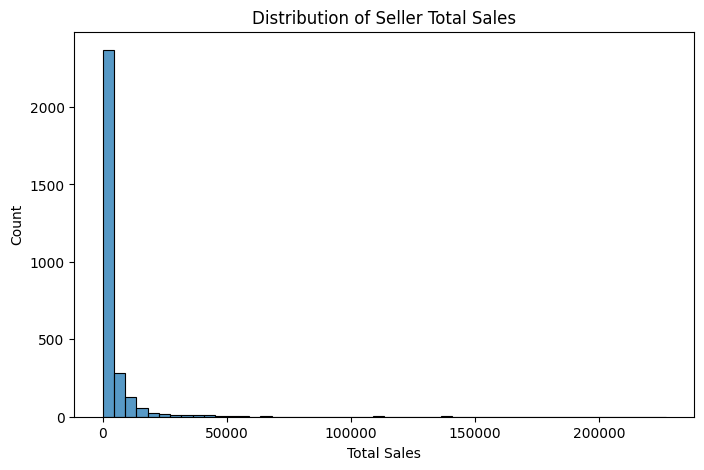

In [10]:
## 9. Explore Sales Distribution
plt.figure(figsize=(8, 5))
sns.histplot(seller_df["total_sales"], bins=50)
plt.title("Distribution of Seller Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Count")
plt.show()

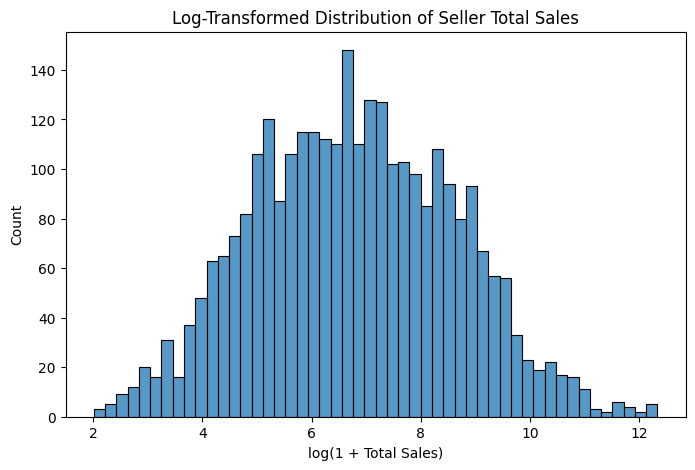

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(seller_df["total_sales"]), bins=50)
plt.title("Log-Transformed Distribution of Seller Total Sales")
plt.xlabel("log(1 + Total Sales)")
plt.ylabel("Count")
plt.show()

In [12]:
## 10. Seller Segmentation by Sales
q50 = seller_df["total_sales"].quantile(0.50)
q90 = seller_df["total_sales"].quantile(0.90)

def sales_group(x):
    if x >= q90:
        return "Top 10%"
    elif x >= q50:
        return "Middle 40%"
    else:
        return "Bottom 50%"

seller_df["sales_group"] = seller_df["total_sales"].apply(sales_group)

seller_df["sales_group"].value_counts()

sales_group
Bottom 50%    1485
Middle 40%    1188
Top 10%        297
Name: count, dtype: int64

판매자를 총매출 기준으로 하위 50%, 중위 40%, 상위 10%로 나누었다. 이 구분은 단순 평균 비교보다 더 명확하게 “성공한 판매자 집단”의 특징을 드러내기 위한 것이다. 특히 상위 10%를 별도 집단으로 둔 것은, Olist 시장이 롱테일 구조이기 때문에 소수의 고성과 판매자를 집중적으로 분석하는 것이 의미가 있기 때문이다.

In [ ]:
## 11. Compare Seller Characteristics by Sales Group
# We compare seller features across low-, middle-, and high-sales groups.
group_summary = (
    seller_df.groupby("sales_group")
    .agg(
        sellers=("seller_id", "count"),
        avg_sales=("total_sales", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_review=("avg_review_score", "mean"),
        avg_delivery=("avg_delivery_time", "mean"),
        avg_delay=("avg_delay_days", "mean"),
        avg_delay_rate=("delay_rate", "mean"),
        avg_same_state=("same_state_ratio", "mean"),
        avg_category_diversity=("category_diversity", "mean"),
        avg_price=("avg_price", "mean"),
        avg_freight_ratio=("freight_to_sales_ratio", "mean")
    )
    .round(3)
)

group_summary

,sellers,avg_sales,avg_orders,avg_review,avg_delivery,avg_delay,avg_delay_rate,avg_same_state,avg_category_diversity,avg_price,avg_freight_ratio
sales_group,,,,,,,,,,,
Bottom 50%,1485,295.576,3.834,4.184,11.198,-12.337,0.068,0.359,1.419,95.969,0.337
Middle 40%,1188,3302.815,28.040,4.128,12.085,-12.232,0.069,0.327,2.580,250.146,0.200
Top 10%,297,30024.119,198.027,4.076,12.672,-12.320,0.070,0.309,4.125,295.448,0.157


- 해석 1: 고매출 판매자는 주문량이 압도적으로 많다
상위 10% 판매자의 평균 주문수는 약 198건으로, 하위 50%의 3.8건에 비해 매우 크다. 즉, 고매출은 단순히 고가 상품 몇 개를 팔아서 만들어진 것이 아니라, 지속적이고 많은 주문량에서 비롯된 구조라고 볼 수 있다.
- 해석 2: 카테고리 다양성과 평균 가격이 높다
고매출 판매자는 더 다양한 카테고리를 다루고, 평균 판매 가격도 더 높다. 이는 상위 판매자가 단순히 한 상품만 잘 파는 것이 아니라, 상품 포트폴리오를 넓게 운영하면서 상대적으로 더 높은 가격대의 상품도 함께 판매하고 있음을 시사한다.
- 해석 3: 리뷰 점수는 오히려 약간 낮다
고매출 판매자가 반드시 더 좋은 리뷰를 받는 것은 아니다. 오히려 평균 리뷰는 하위 판매자보다 약간 낮다. 다양한 고객을 상대하게 되어 평가의 분산이 커질 수 있고, 대규모 판매 과정에서 일부 불만족 경험도 함께 증가할 가능성을 의미한다.
- 해석 4: 배송 관련 성과는 큰 차이가 없다
상위 판매자가 특별히 더 빠르게 배송하거나 지연을 더 잘 관리하는 것은 아니다. 오히려 평균 배송시간은 약간 더 길고, 지연률도 거의 비슷하거나 조금 높다.
- 해석 5: 동일 주 판매 비율은 오히려 낮다
상위 판매자는 고객과 같은 주에서 판매되는 비율이 더 낮다. 이는 고매출 판매자가 지역적으로 더 넓은 시장을 대상으로 판매하고 있음을 의미한다.
- 해석 6: 배송비 부담 구조가 더 효율적이다
고매출 판매자는 매출 대비 배송비 비중이 더 낮다. 이는 상품 가격이 높거나, 물류 효율이 좋거나, 배송비 구조가 더 잘 설계되어 있다는 뜻으로 해석할 수 있다.

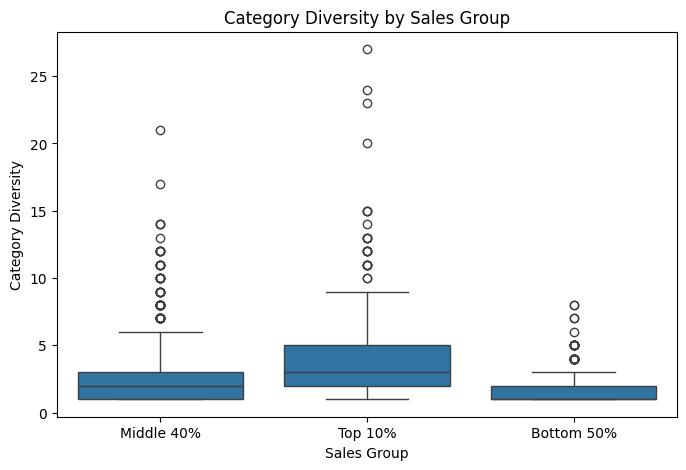

In [ ]:
### Category Diversity by Sales Group
# We test whether high-sales sellers offer a wider variety of product categories.

plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="category_diversity")
plt.title("Category Diversity by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Category Diversity")
plt.show()

고매출 판매자의 중요한 특징 중 하나가 상품군 확장 능력임을 확인가능

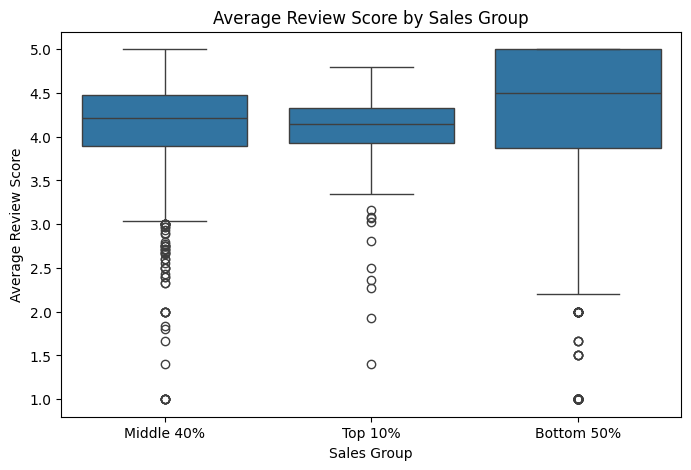

In [15]:
### Review Score by Sales Group
# We compare whether top sellers receive better customer ratings.
plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="avg_review_score")
plt.title("Average Review Score by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Average Review Score")
plt.show()

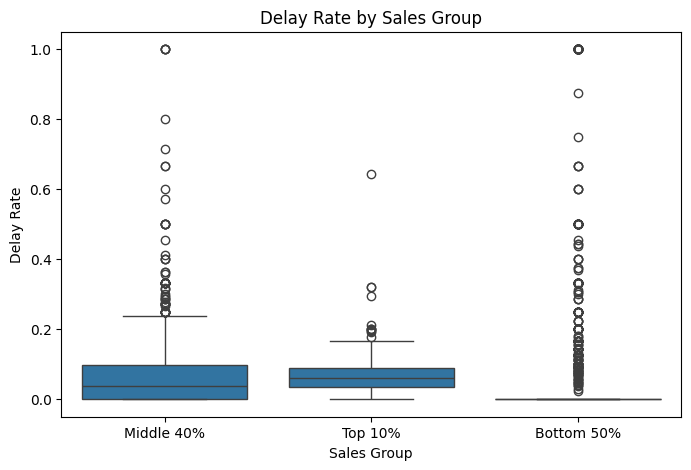

In [16]:
### Delay Rate by Sales Group

# We examine whether top sellers differ in delivery performance.
plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="delay_rate")
plt.title("Delay Rate by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Delay Rate")
plt.show()

In [17]:
## 12. Statistical Tests
features_to_test = [
    "category_diversity",
    "avg_review_score",
    "avg_delivery_time",
    "delay_rate",
    "same_state_ratio",
    "avg_price",
    "freight_to_sales_ratio"
]

results = []

for col in features_to_test:
    g1 = seller_df.loc[seller_df["sales_group"] == "Bottom 50%", col].dropna()
    g2 = seller_df.loc[seller_df["sales_group"] == "Middle 40%", col].dropna()
    g3 = seller_df.loc[seller_df["sales_group"] == "Top 10%", col].dropna()
    
    stat, p = kruskal(g1, g2, g3)
    results.append([col, stat, p])

kw_results = pd.DataFrame(results, columns=["feature", "kruskal_stat", "p_value"])
kw_results = kw_results.sort_values("p_value")
kw_results

,feature,kruskal_stat,p_value
0,category_diversity,531.695202,3.498274e-116
3,delay_rate,513.018925,3.975172e-112
5,avg_price,503.375017,4.937464e-110
6,freight_to_sales_ratio,364.262417,7.969317e-80
2,avg_delivery_time,142.275583,1.274235e-31
1,avg_review_score,114.308338,1.507509e-25
4,same_state_ratio,6.570810,3.742542e-02


Kruskal-Wallis 검정 결과, 대부분의 변수는 판매자 그룹 간 차이가 통계적으로 유의했다.
판매자 성과 수준에 따라 특성이 다르게 나타날 가능성이 높다는 뜻이다.

In [18]:
## 13. Define Prediction Target
# We define top sellers as the top 10%
# build a binary classification problem
seller_df["is_top_seller"] = (seller_df["total_sales"] >= q90).astype(int)
seller_df["is_top_seller"].value_counts(normalize=True)

is_top_seller
0    0.9
1    0.1
Name: proportion, dtype: float64

상위 판매자는 전체의 10%로 보았기에, 단순 정확도만 보면 모델이 좋아 보일 수 있으므로, F1-score나 ROC AUC 같은 지표를 보는 것이 중요하다.

In [19]:
## 14. Select Predictive Features
# We exclude direct sales outcome variables and focus on seller characteristics that may explain top-seller status.
feature_cols = [
    "category_diversity",
    "avg_review_score",
    "avg_delivery_time",
    "avg_delay_days",
    "delay_rate",
    "same_state_ratio",
    "avg_price",
    "avg_freight_per_item",
    "freight_to_sales_ratio",
    "avg_weight_g"
]

X = seller_df[feature_cols].copy()
y = seller_df["is_top_seller"].copy()

X.head()

,category_diversity,avg_review_score,avg_delivery_time,avg_delay_days,delay_rate,same_state_ratio,avg_price,avg_freight_per_item,freight_to_sales_ratio,avg_weight_g
0,1,3.666667,10.333333,-16.333333,0.000000,0.000000,895.000000,21.020000,0.023486,11800.000000
1,2,3.965368,12.628205,-13.213675,0.051282,0.025641,104.645427,36.990897,0.353488,8976.709402
2,1,4.036364,15.636364,-8.218182,0.163636,0.454545,22.481818,14.388182,0.639992,331.818182
3,1,5.000000,4.000000,-27.000000,0.000000,0.000000,120.000000,19.380000,0.161500,1200.000000
4,2,4.145349,14.327586,-11.614943,0.068966,0.367816,116.805747,20.873793,0.178705,2449.896552


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
## 15. RandomForest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred_proba))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91       535
           1       0.37      0.78      0.50        59

    accuracy                           0.84       594
   macro avg       0.67      0.82      0.70       594
weighted avg       0.91      0.84      0.87       594

ROC AUC: 0.9078092824330747


상위 판매자인 1을 재현율(recall) 0.78을 통해 실제 상위 판매자 중 많은 비율을 잡아냈다는 것을 알 수 있음. 다만 precision이 0.37로 낮은 편이어서, 상위 판매자로 예측한 대상 중 실제 상위 판매자가 아닌 경우도 꽤 존재.   
상위 판매자 후보를 넓게 탐색하는 목적에는 유용하지만, 예측 대상을 매우 정밀하게 좁히는 데는 한계가 있음

In [22]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

,feature,importance
4,delay_rate,0.325948
8,freight_to_sales_ratio,0.127634
1,avg_review_score,0.113399
6,avg_price,0.104792
5,same_state_ratio,0.097786
3,avg_delay_days,0.070701
2,avg_delivery_time,0.068778
0,category_diversity,0.044854
7,avg_freight_per_item,0.027758
9,avg_weight_g,0.018348


랜덤포레스트에서는 delay_rate가 가장 중요한 변수였다.   
즉, 배송 지연 관리가 상위 판매자 여부를 설명하는 데 가장 큰 역할을 했다.

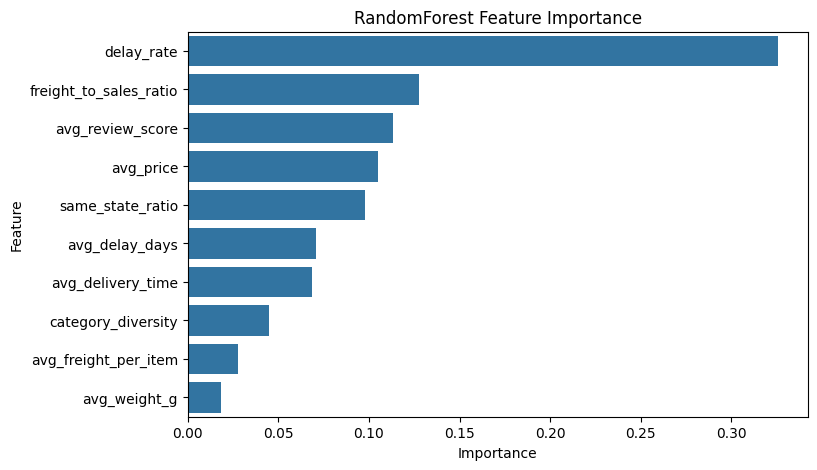

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x="importance", y="feature")
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [24]:
## 16. XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_pred_proba))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       535
           1       0.55      0.46      0.50        59

    accuracy                           0.91       594
   macro avg       0.75      0.71      0.72       594
weighted avg       0.90      0.91      0.91       594

ROC AUC: 0.9143354981783622


위의 랜덤포리스트 모델에 비해서 recall은 낮아졌고 precision은 높아졌다. 즉, XGBoost는 랜덤포레스트보다 더 보수적으로 상위 판매자를 예측하는 경향이 있다.

In [25]:
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance

,feature,importance
4,delay_rate,0.250324
8,freight_to_sales_ratio,0.110432
0,category_diversity,0.104643
6,avg_price,0.103463
3,avg_delay_days,0.090645
1,avg_review_score,0.088200
5,same_state_ratio,0.087564
2,avg_delivery_time,0.061746
7,avg_freight_per_item,0.052196
9,avg_weight_g,0.050787


XGBoost에서도 delay_rate가 가장 중요한 변수로 나타났다. 즉, 두 모델 모두 공통적으로 배송 지연 관리가 핵심 요인이라는 점을 지지한다.

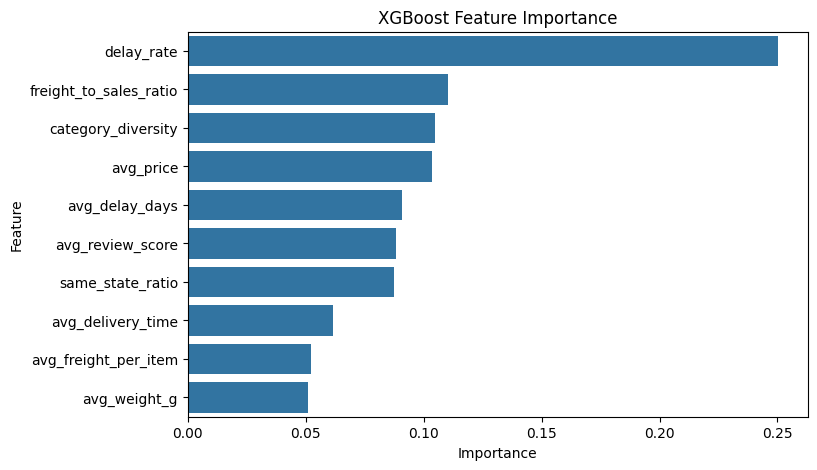

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance, x="importance", y="feature")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [27]:
## 17. Compare Model Insights
importance_compare = rf_importance.merge(
    xgb_importance,
    on="feature",
    suffixes=("_rf", "_xgb")
)

importance_compare["avg_importance"] = (
    importance_compare["importance_rf"] + importance_compare["importance_xgb"]
) / 2

importance_compare = importance_compare.sort_values("avg_importance", ascending=False)
importance_compare

,feature,importance_rf,importance_xgb,avg_importance
0,delay_rate,0.325948,0.250324,0.288136
1,freight_to_sales_ratio,0.127634,0.110432,0.119033
3,avg_price,0.104792,0.103463,0.104128
2,avg_review_score,0.113399,0.088200,0.100800
4,same_state_ratio,0.097786,0.087564,0.092675
5,avg_delay_days,0.070701,0.090645,0.080673
7,category_diversity,0.044854,0.104643,0.074748
6,avg_delivery_time,0.068778,0.061746,0.065262
8,avg_freight_per_item,0.027758,0.052196,0.039977
9,avg_weight_g,0.018348,0.050787,0.034568


두 모델의 중요도를 종합하면, 상위 판매자를 설명하는 핵심 특성은 다음과 같이 정리된다.

배송 지연률이 낮거나 안정적인 판매자

매출 대비 배송비 비율이 효율적인 판매자

평균 가격대가 더 높은 판매자

고객 리뷰가 일정 수준 이상 유지되는 판매자

카테고리를 더 다양하게 운영하는 판매자

In [28]:
## 19. Baseline Comparison
baseline_pred = np.repeat(y_train.mode()[0], len(y_test))

from sklearn.metrics import accuracy_score, f1_score

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline F1:", f1_score(y_test, baseline_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF F1:", f1_score(y_test, rf_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB F1:", f1_score(y_test, xgb_pred))

Baseline Accuracy: 0.9006734006734006
Baseline F1: 0.0
RF Accuracy: 0.8434343434343434
RF F1: 0.4972972972972973
XGB Accuracy: 0.9090909090909091
XGB F1: 0.5


클래스 불균형 때문에 아무 판매자도 상위 판매자라고 예측하지 않아도 baseline accuracy는 0.90이 나온다. 하지만 이 경우 상위 판매자를 전혀 맞추지 못하므로 F1은 0이다.
반면 RF와 XGB는 F1이 약 0.5 수준으로 나타나, 단순 다수 클래스 예측보다 훨씬 실질적인 예측력을 가지는 것을 확인할 수 있는 것이다.

In [29]:
## 20. Top Seller vs Non-Top Seller Test
# Directly compare top sellers against all other sellers.
seller_df["top_group"] = np.where(seller_df["is_top_seller"] == 1, "Top 10%", "Others")

mw_results = []

for col in features_to_test:
    a = seller_df.loc[seller_df["top_group"] == "Top 10%", col].dropna()
    b = seller_df.loc[seller_df["top_group"] == "Others", col].dropna()
    
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    mw_results.append([col, stat, p])

mw_results = pd.DataFrame(mw_results, columns=["feature", "mw_stat", "p_value"])
mw_results.sort_values("p_value")

,feature,mw_stat,p_value
0,category_diversity,578341.5,1.135015e-45
3,delay_rate,570645.0,6.285983e-43
5,avg_price,553377.5,6.519328e-29
6,freight_to_sales_ratio,244580.0,1.645195e-27
2,avg_delivery_time,502277.5,5.742344e-14
1,avg_review_score,314311.0,3.332414e-09
4,same_state_ratio,406907.5,4.728503e-01


Top 10%와 나머지 판매자를 주어진 매출데이터로 구분하여 직접 비교했을 때, 대부분의 변수는 유의한 차이를 보였다.   
카테고리 다양성, 지연률, 평균 가격, 배송비/매출 비율은 상위 판매자와 일반 판매자를 강하게 구분하는 변수였다.
반면 same_state_ratio는 유의하지 않았다(p=0.473).
즉, 상위 판매자가 같은 주 고객에게 더 많이 판매하는지는 뚜렷한 차이가 없었다.
지역 일치 자체보다는, 전반적인 운영 효율과 상품 전략이 더 중요하다는 해석을 뒷받침

# 최종 인사이트
Olist 데이터에서 고매출 판매자는 단순히 배송이 빠르거나 리뷰가 높은 판매자라기보다, 더 많은 주문을 처리하면서도 상품 카테고리를 다양하게 운영하고, 평균 가격이 높은 상품을 판매하며, 배송비 부담을 상대적으로 효율적으로 관리하는 판매자로 나타났다.
또한 머신러닝 모델 결과에서도 delay_rate, freight_to_sales_ratio, avg_price, category_diversity가 핵심 변수로 반복적으로 나타나, 상위 판매자의 성공은 물류 안정성, 가격 전략, 상품 포트폴리오 운영 능력의 결합으로 설명될 가능성이 높다.
즉, 판매자 성과는 단일 요인보다 운영 구조 전반의 경쟁력에서 차이가 난다고 해석할 수 있다.